In [ ]:
!pip install pandas scikit-learn torch transformers tqdm pennylane

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 11.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import json
import urllib.parse
import base64
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import re
import pennylane as qml
from pennylane import numpy as np
import torch.nn.functional as F

In [ ]:
# Load and preprocess dataset
df = pd.read_csv("Modified_SQL_Dataset.csv").sample(10000).reset_index(drop=True)

def decode_sql(encoded_string):
    decoded_string = encoded_string
    try:
        decoded_string = bytes.fromhex(encoded_string).decode('ascii')
    except:
        pass
    return decoded_string

def lowercase_sql(query):
    return query.lower()

def generalize_sql(query):
    generalized_query = re.sub(r'\d+', '0', query)
    return generalized_query

def tokenize_sql(query):
    query = re.sub(r'([<>!=])', r' \1 ', query)  # Separate operators with spaces.
    tokens = query.split()
    return ' '.join(tokens)

In [ ]:
df['Text'] = df['Query'].apply(decode_sql)
df['Text'] = df['Text'].apply(lowercase_sql)
df['Text'] = df['Text'].apply(generalize_sql)
df['Text'] = df['Text'].apply(tokenize_sql)

train_df, test_df = train_test_split(df, test_size=0.20, random_state=50, shuffle=True)
train_texts, train_labels = train_df['Text'].tolist(), train_df['Label'].tolist()
test_texts, test_labels = test_df['Text'].tolist(), test_df['Label'].tolist()

In [ ]:
# Define custom dataset
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Quantum circuit setup
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_circuit(inputs):
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    qml.CNOT(wires=[n_qubits - 1, 0])
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [ ]:
# Quantum-inspired classifier
class QuantumInspiredClassifier(nn.Module):
    def __init__(self, bert_model, num_filters, filter_sizes, output_size):
        super(QuantumInspiredClassifier, self).__init__()
        self.bert_model = bert_model
        self.num_filters = num_filters
        self.filter_sizes = filter_sizes

        # CNN layers
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=bert_model.config.hidden_size, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(num_filters * len(filter_sizes) + n_qubits, output_size)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert_model(input_ids=input_ids, attention_mask=attention_mask)
        embedded = outputs.last_hidden_state.transpose(1, 2)

        pooled_outputs = []
        for conv_layer in self.conv_layers:
            conv_out = F.relu(conv_layer(embedded))
            pooled_out, _ = torch.max(conv_out, dim=2)
            pooled_outputs.append(pooled_out)

        cnn_features = torch.cat(pooled_outputs, dim=1)
        cnn_features = self.dropout(cnn_features)

        quantum_features = []
        for batch_idx in range(cnn_features.size(0)):
            quantum_input = cnn_features[batch_idx, :n_qubits].detach().cpu().numpy()
            quantum_output = quantum_circuit(quantum_input)
            quantum_features.append(quantum_output)
        quantum_features = torch.tensor(quantum_features, device=cnn_features.device, dtype=torch.float32) # Cast to torch.float32

        hybrid_features = torch.cat([cnn_features, quantum_features], dim=1)
        logits = self.fc(hybrid_features)
        return logits

In [ ]:
# Set hyperparameters
batch_size = 64
max_length = 128
output_size = 2
num_filters = 100
filter_sizes = [2, 3, 4]
num_epochs = 1

# Tokenizer and model setup
bert_model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(bert_model_name)
bert_model = BertModel.from_pretrained(bert_model_name)

train_dataset = CustomDataset(train_texts, train_labels, tokenizer, max_length)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = CustomDataset(test_texts, test_labels, tokenizer, max_length)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

model = QuantumInspiredClassifier(bert_model, num_filters, filter_sizes, output_size)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

QuantumInspiredClassifier(
  (bert_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=

Start training


100%|██████████| 125/125 [1:11:42<00:00, 34.42s/batch, loss=0.39, accuracy=0.875]


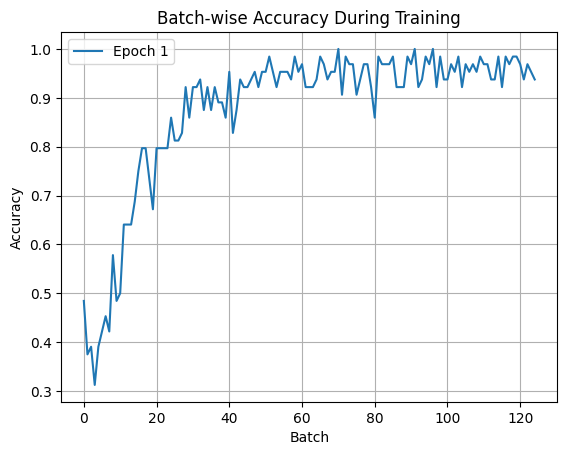

In [ ]:
import matplotlib.pyplot as plt

# Training loop
print("Start training")
model.train()
batch_accuracies = []  # To store accuracies for each batch

for epoch in range(num_epochs):
    total_loss = 0
    correct_train = 0
    total_train = 0
    batch_accuracies.clear()  # Clear previous epoch's accuracies

    with tqdm(train_loader, unit="batch") as t:
        for batch in t:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            # Calculate and store batch accuracy
            batch_accuracy = (predicted == labels).sum().item() / labels.size(0)
            batch_accuracies.append(batch_accuracy)

            t.set_postfix({'loss': total_loss / (t.n + 1), 'accuracy': correct_train / total_train})

    # Plot batch-wise accuracy for the epoch
    plt.plot(batch_accuracies, label=f"Epoch {epoch + 1}")
    plt.xlabel("Batch")
    plt.ylabel("Accuracy")
    plt.title("Batch-wise Accuracy During Training")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    with tqdm(test_loader, unit="batch") as t:
        for batch in t:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            _, predicted = torch.max(logits.data, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


100%|██████████| 32/32 [14:53<00:00, 27.91s/batch]

Test Accuracy: 0.9750
Precision: 0.9877
Recall: 0.9465
F1-score: 0.9667


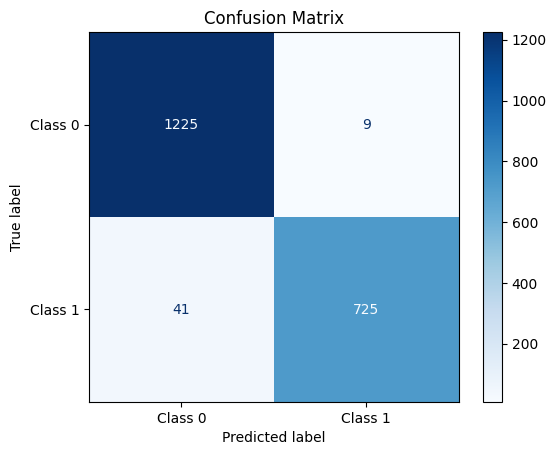

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


